# Bagaimana Menghitung Moving Average pada Pandas DataFrame

Tutorial by [GeeksforGeeks](https://www.geeksforgeeks.org/how-to-calculate-moving-average-in-a-pandas-dataframe/)

In this article, we will be looking at how to calculate the moving average in a Pandas data frame. Moving Average calculates the average of data over some periods. The moving average is also known as the rolling mean and is calculated by averaging data of the time series within k periods.

## Simple Moving Average (SMA)

To calculate a Simple Moving Average in Pandas DataFrame we will use Pandas `dataframe.rolling()` action that helps us to make calculations on a rolling window. On the rolling window, we will use `.mean()` function to calculate the mean of each window.

---
Syntax:
```python
DataFrame.rolling(window, min_periods=None, center=False, win_type=None, on=None, axis=0).mean()
```
Parameters:
* **window**: Size of the window. That is how many observations we have to take for the calculation of each window.
* **min_periods**: Least number of observations in a window required to have a value (otherwise result is NA).
* **center**: It is used to set the labels at the center of the window.
* **win_type**: It is used to set to set the window type.
* **on**: Datetime column of our dataframe on which we have to calculate rolling mean.
* **axis**: integer or string, default 0.
---

**Simple Moving Average (SMA)**

A simple moving average tells us the unweighted mean of the previous *K* data points. The more the value of *K* the more smooth is the curve, but increasing *K* decreases accuracy. If the data points are p<sub>1</sub>, p<sub>2</sub>, ..., p<sub>n</sub> then we calculate the simple moving average.

<img src="../static/img/IMG_20240804_220310.jpg" style="width:45%;">

In Python, we can calculate the moving average using `.rolling()` method. This method provides rolling windows over the data, and we can use the mean function over these windows to calculate moving averages. The size of the window is passed as a parameter in the function `.rolling(window)`.

Now let's see an example of how to calculate a simple rolling mean over a period of 200 days.

### Importing Libraries

In below code we are import the Pandas library as `pd` and the NumPy library as `np` for data manipulation and mathematical calculations, respectively. Additionally, Matplotlib's pyplot module is imported as `plt` for plotting graphs, with the default style set, and `%matplotlib inline` is included to display the plots inline in Jupyter notebooks.

In [ ]:
import os
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
plt.style.use("default")
%matplotlib inline

: 

### Importing Data

Ini adalah percobaan secara offline, maka dari itu kami telah menyediakan dataset berupa file csv dan xlsx di dalam folder [data](../data/) pada proyek ini.

#### 1. Scan seluruh file dataset dengan Library OS

Kami menggunakan function `listdir()` dari Library OS Python, kemudian menampung seluruh nama file dataset ke dalam struktur data list. Lihat pada kode program di bawah ini.

In [9]:
# Folder `data` ini secara default berada di dalam repository
data_path = "..\\data\\"

# Akses isi di dalam folder `data` dengan module python OS
data_list_file = os.listdir(data_path)

# Tampilkan isi folder
data_list_file

['AAPL.csv',
 'AMZN.csv',
 'AMZN.xlsx',
 'BBCA.csv',
 'BBCA.JK.xlsx',
 'CSCO.csv',
 'GOOG.csv',
 'META.csv',
 'models',
 'MSFT.csv',
 'NFLX.csv',
 'NVDA.csv',
 'PTBA.JK.xlsx',
 'PYPL.csv',
 'TSLA.csv',
 '[Join].xlsx']

#### 2. Seleksi Hanya File Dataset CSV

Kami memilih file dataset berformat csv. Pada langkah sebelumnya, setelah melakukan scan isi folder [data](../data/) menggunakan function `listdir()`, daftar nama file di tampung ke dalam struktur data list di dalam variabel `data_list_file`. Kemudian pada langkah ini, kami membuat variabel list kosong bernama `df`. Dari variabel `data_list_file`, kami melakukan perulangan dan melakukan appending terhadap file berformat csv, kemudian memasukkannya ke dalam variabel list kosong `df`.

Hasilnya bisa dilihat pada cell output dibawah kode program berikut ini.

In [10]:
# Buat variabel kosong bernama "df" yang artinya DataFrame.
df = []

# Melakukan perulangan untuk membatasi file berformat CSV saja.
for i in data_list_file:
    if i.endswith(".csv"):
        df.append(data_path + i)

# Tampilkan hanya file berformat CSV
df

['..\\data\\AAPL.csv',
 '..\\data\\AMZN.csv',
 '..\\data\\BBCA.csv',
 '..\\data\\CSCO.csv',
 '..\\data\\GOOG.csv',
 '..\\data\\META.csv',
 '..\\data\\MSFT.csv',
 '..\\data\\NFLX.csv',
 '..\\data\\NVDA.csv',
 '..\\data\\PYPL.csv',
 '..\\data\\TSLA.csv']

#### 3. Baca Isi Dataset

Terakhir dalam tahap import data, yaitu menggunakan function `read_csv()` pada Library Pandas. Karena alamat directory file dataset tersimpan dalam bentuk list, maka untuk membaca tiap dataset perlu menggunakan index. Sebagai contoh, kami memilih dataset saham AAPL pada index ke-0. Kami membuat variabel bernama `apple` yang berisi dataset harga saham Apple.

In [18]:
apple = pd.read_csv(df[0], index_col="Date", parse_dates=True)
apple


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099449,469033600,0.0,0.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094261,175884800,0.0,0.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087343,105728000,0.0,0.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089504,86441600,0.0,0.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092099,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
2023-09-12,179.490005,180.130005,174.820007,176.300003,176.300003,90370200,0.0,0.0
2023-09-13,176.509995,177.300003,173.979996,174.210007,174.210007,84267900,0.0,0.0
2023-09-14,174.000000,176.100006,173.580002,175.740005,175.740005,60895800,0.0,0.0


### Dataframe by extract Columns

In this example the below code refines `apple` DataFrame by extracting the `Close` column, computes a 200-day SMA, and prints the cleaned DataFrame, a standard step in financial analysis for technical indicator computation.

In [19]:
# Extract "Close" column and convert to DataFrame
apple = apple["Close"].to_frame()

# Calculate 200-day Simple Moving Average (SMA-200)
apple["SMA200"] = apple["Close"].rolling(200).mean()

# Remove NULL values
apple.dropna(inplace=True)

# Print DataFrame
apple

,Close,SMA200
Date,,
1981-09-28,0.064174,0.118125
1981-09-29,0.067522,0.117821
1981-09-30,0.068080,0.117553
1981-10-01,0.068080,0.117330
1981-10-02,0.073661,0.117120
...,...,...
2023-09-12,176.300003,164.331650
2023-09-13,174.210007,164.447350
2023-09-14,175.740005,164.585500


### Plotting Simple Moving Averages

In this example the code uses the `.plot()` method to visualize the Close price and a 200-day Simple Moving Average (SMA) of the 'apple' DataFrame, with 'AAPL' as the label, and a specified figure size of 16x8.

<Axes: xlabel='Date'>

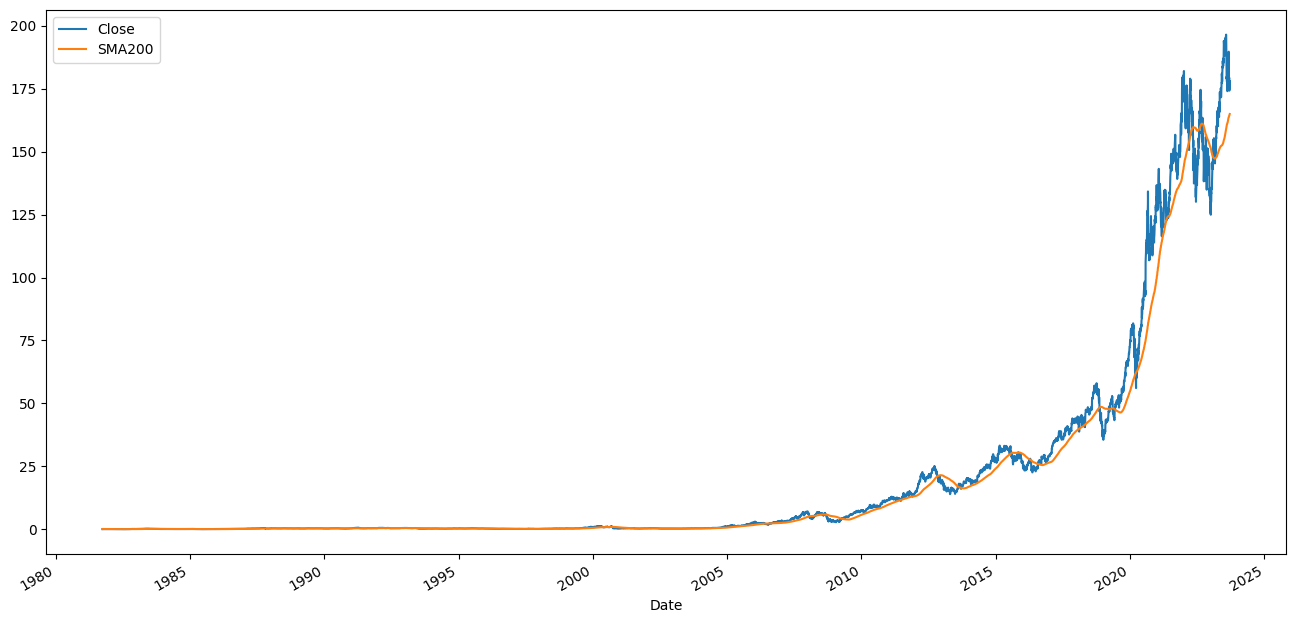

In [21]:
apple[["Close", "SMA200"]].plot(label="AAPL", figsize=(16, 8))

## Exponential Moving Average (EMA)

To calculate exponential moving average in Pandas Dataframe use `dataframe.ewm()` function. It provides us exponentially weighted functions. We will be using `.mean()` function to calculate EMA.

---
Syntax:
```python
DataFrame.ewm(com=None, span=None, halflife=None, alpha=None, min_periods=0,
                adjust=True, ignore_na=False, axis=0, times=None).mean()
```
Parameters:
* **com**: float, optional. It is the decay in terms of centre of mass.
* **span**: float, optional. It is the decay in terms of span.
* **halflife**: float, str, timedelta, optional. It is the decay in terms of halflife.
* **alpha**: float, optional. It is the smoothing factor having value between 0 and 1, 1 inclusive.
* **min_periods**: int, default 0. Least number of observations in a window required to have a value (otherwise result is NA).
* **adjust**: bool, default True. Divide by decaying adjustment factor in beginning periods to account for imbalance in relative weightings (viewing EWMA as a moving average).
* **ignore_na**: Ignore missing values when calculating weights; specify True to reproduce pre-0.15.0 behavior.
* **axis**: The axis to use. The value 0 identifies the rows, and 1 identifies the columns.
---

**Exponential Moving Average**

Exponential Moving Average (EMA) tells us the weighted mean of the previous *K* data points. EMA places a greater weight and significance on the most recent data points. The formula to calculate EMA at the time period t is:

<img src="../static/img/IMG_20240804_234739.jpg" style="width:45%;">

where x<sub>t</sub> is the value of observation at time t & &alpha; is the smoothing factor. In Python, EMA is calculated using `.ewm()` method. We can pass span or window as a parameter to `.ewm(span=)` method. Now we will be looking at an example to calculate EMA for a period of 20 days.

#### 1. Baca Isi Dataset

Pada langkah sebelumnya, kami sudah melakukan *listing* alamat folder tempat dataset tersimpan. Saat ini alamat folder file dataset yang berekstensi .csv telah tersimpan dalam variabel `df` sebagai list Python. Pada contoh sebelumnya kami mendefinisikan nama variabel `apple` yang berisi DataFrame harga saham AAPL, diambil dari `df[0]`. Selanjutnya kami akan memakai harga saham Microsoft, yang pada variabel `df` berada pada index ke-6.

In [22]:
# Alamat folder pada variabel df
df

['..\\data\\AAPL.csv',
 '..\\data\\AMZN.csv',
 '..\\data\\BBCA.csv',
 '..\\data\\CSCO.csv',
 '..\\data\\GOOG.csv',
 '..\\data\\META.csv',
 '..\\data\\MSFT.csv',
 '..\\data\\NFLX.csv',
 '..\\data\\NVDA.csv',
 '..\\data\\PYPL.csv',
 '..\\data\\TSLA.csv']

In [23]:
# Definisikan variabel DataFrame untuk harga saham Microsoft
microsoft = pd.read_csv(df[6], index_col="Date", parse_dates=True)

# Print dataframe
microsoft

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
1986-03-13,0.088542,0.101563,0.088542,0.097222,0.060396,1031788800,0.0,0.0
1986-03-14,0.097222,0.102431,0.097222,0.100694,0.062553,308160000,0.0,0.0
1986-03-17,0.100694,0.103299,0.100694,0.102431,0.063632,133171200,0.0,0.0
1986-03-18,0.102431,0.103299,0.098958,0.099826,0.062014,67766400,0.0,0.0
1986-03-19,0.099826,0.100694,0.097222,0.098090,0.060936,47894400,0.0,0.0
...,...,...,...,...,...,...,...,...
2023-09-12,335.820007,336.790009,331.480011,331.769989,331.769989,17565500,0.0,0.0
2023-09-13,331.309998,336.850006,331.170013,336.059998,336.059998,16544400,0.0,0.0
2023-09-14,339.149994,340.859985,336.570007,338.700012,338.700012,20267000,0.0,0.0


#### 2. Isolates Column by Dataframe

In this example the below code isolates the 'Close' column in the 'microsoft' DataFrame, converts it into a DataFrame, computes the Exponential Moving Average (EWMA) with a span of 20 for the 'Close' column, and prints the resulting DataFrame containing the EWMA values.

In [32]:
# Extract and isolate 'Close' column, coverting to DataFrame
microsoft = microsoft["Close"].to_frame()

# Calculate Exponential Moving Average (EWMA) with a span of 20
microsoft["EMA-5"] = microsoft["Close"].ewm(span=5).mean()
microsoft["EMA-20"] = microsoft["Close"].ewm(span=20).mean()

# Print dataframe
microsoft

,Close,EMA-5,EMA-20
Date,,,
1986-03-13,0.097222,0.097222,0.097222
1986-03-14,0.100694,0.099305,0.099045
1986-03-17,0.102431,0.100786,0.100288
1986-03-18,0.099826,0.100387,0.100155
1986-03-19,0.098090,0.099505,0.099655
...,...,...,...
2023-09-12,331.769989,333.085499,329.508284
2023-09-13,336.059998,334.076999,330.132257
2023-09-14,338.700012,335.618003,330.948234


#### 3. Plotting Exponential Moving Averages

Here, code uses the `.plot()` method to visualize the Close price and a 20-day Exponential Moving Average (EWMA) of the Microsoft stock, displaying them on the same plot with a specified label and figure size.

<Axes: xlabel='Date'>

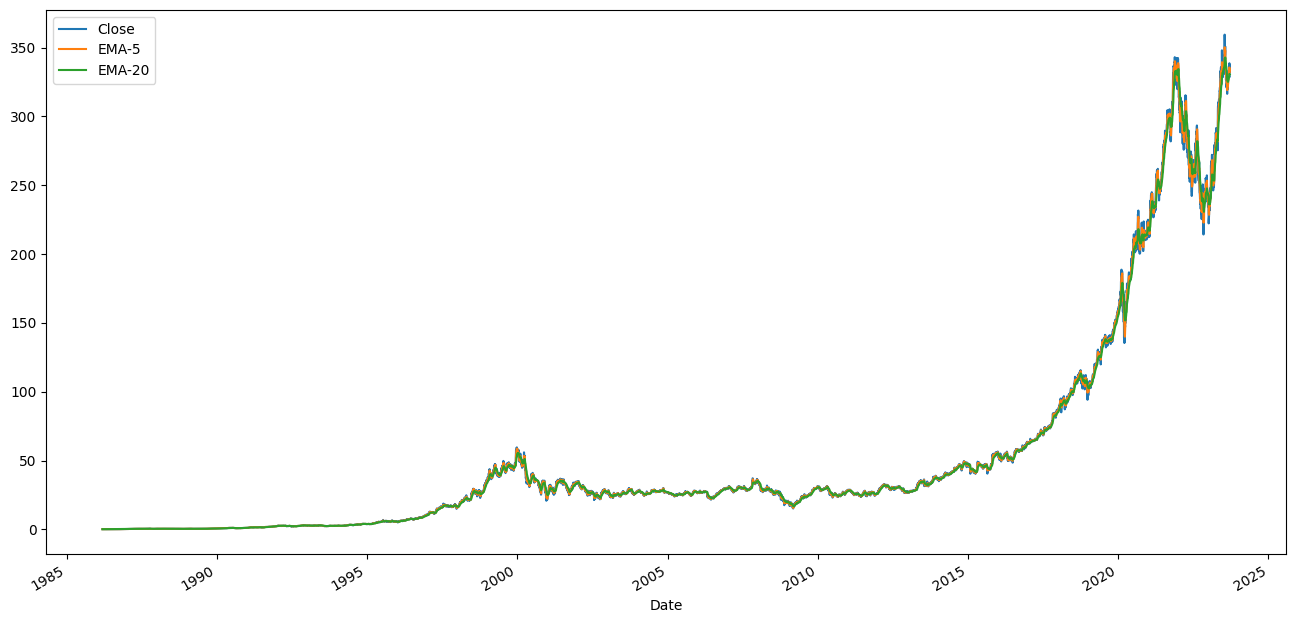

In [31]:
microsoft[["Close", "EMA-5", "EMA-20"]].plot(label="MSFT", figsize=(16, 8))